In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt    

In [3]:
df_clean = pd.read_csv("\Pós\data\clean_df.csv")


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\cutie\AppData\Local\Temp\ipykernel_1972\2596156368.py:1: SyntaxWarning: invalid escape sequence '\P'
  df_clean = pd.read_csv("\Pós\data\clean_df.csv")


In [4]:
df_clean

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,2013,1,1,05:17,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,02:27,1400,5.0,17.0
1,2013,1,1,05:33,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,02:27,1416,5.0,33.0
2,2013,1,1,05:54,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,01:16,762,5.0,54.0
3,2013,1,1,05:54,-4.0,740.0,12.0,UA,N39463,1696,EWR,ORD,01:50,719,5.0,54.0
4,2013,1,1,05:55,-5.0,913.0,19.0,B6,N516JB,507,EWR,FLL,01:58,1065,5.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229623,2013,9,30,22:37,-8.0,2345.0,-8.0,B6,N318JB,234,JFK,BTV,00:43,266,22.0,37.0
229624,2013,9,30,22:40,-5.0,2334.0,-17.0,B6,N354JB,1816,JFK,SYR,00:41,209,22.0,40.0
229625,2013,9,30,22:40,-10.0,2347.0,-20.0,B6,N281JB,2002,JFK,BUF,00:52,301,22.0,40.0
229626,2013,9,30,22:41,-5.0,2345.0,-16.0,B6,N346JB,486,JFK,ROC,00:47,264,22.0,41.0


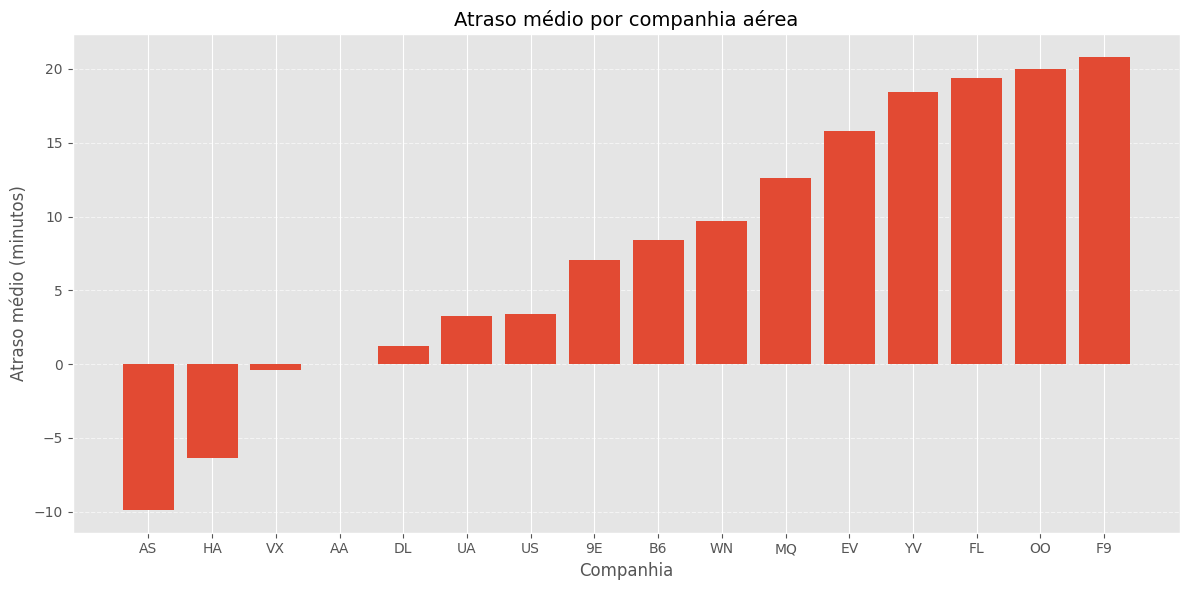

In [5]:
data = df_clean.groupby('carrier')['arr_delay'].mean().sort_values()

plt.style.use('ggplot')
plt.figure(figsize=(12,6))

plt.bar(data.index, data.values)


plt.title("Atraso médio por companhia aérea", fontsize=14)
plt.xlabel("Companhia", fontsize=12)
plt.ylabel("Atraso médio (minutos)", fontsize=12)



plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()


plt.show()


In [6]:
total_voos = df_clean['carrier'].value_counts()
total_atrasos = df_clean[df_clean['arr_delay'] > 0]['carrier'].value_counts()

proporcao = (total_atrasos / total_voos).sort_values(ascending=True) * 100

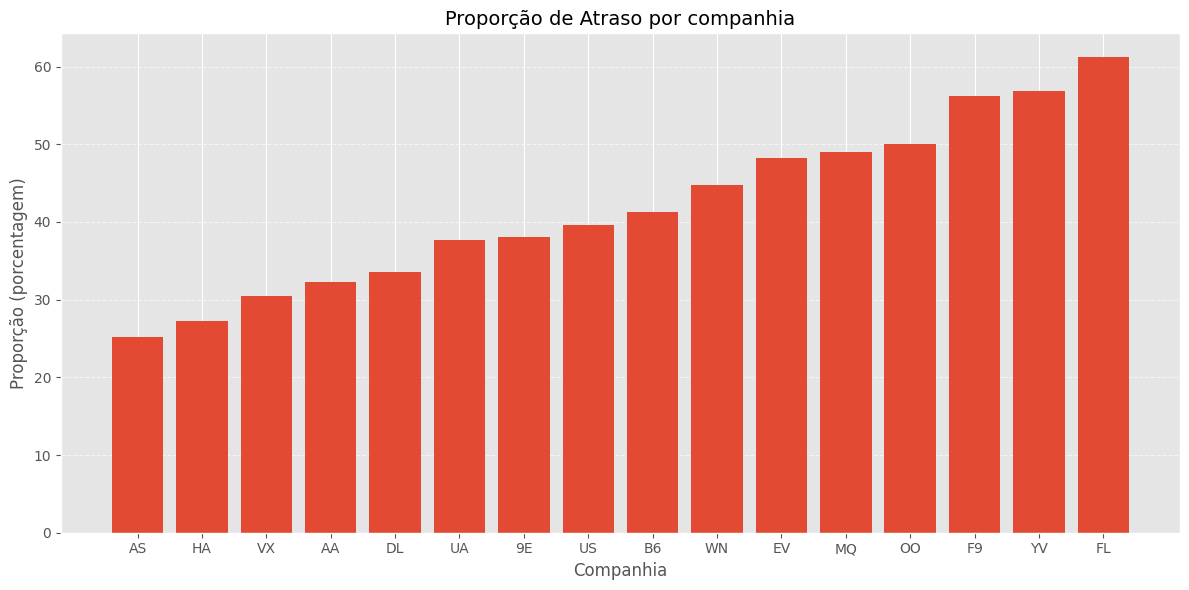

In [7]:
plt.style.use('ggplot')
plt.figure(figsize=(12,6))

plt.bar(proporcao.index, proporcao.values)


plt.title("Proporção de Atraso por companhia", fontsize=14)
plt.xlabel("Companhia", fontsize=12)
plt.ylabel("Proporção (porcentagem)", fontsize=12)



plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()


plt.show()


In [8]:
total_atrasos = df_clean.groupby('carrier')['arr_delay'].sum()

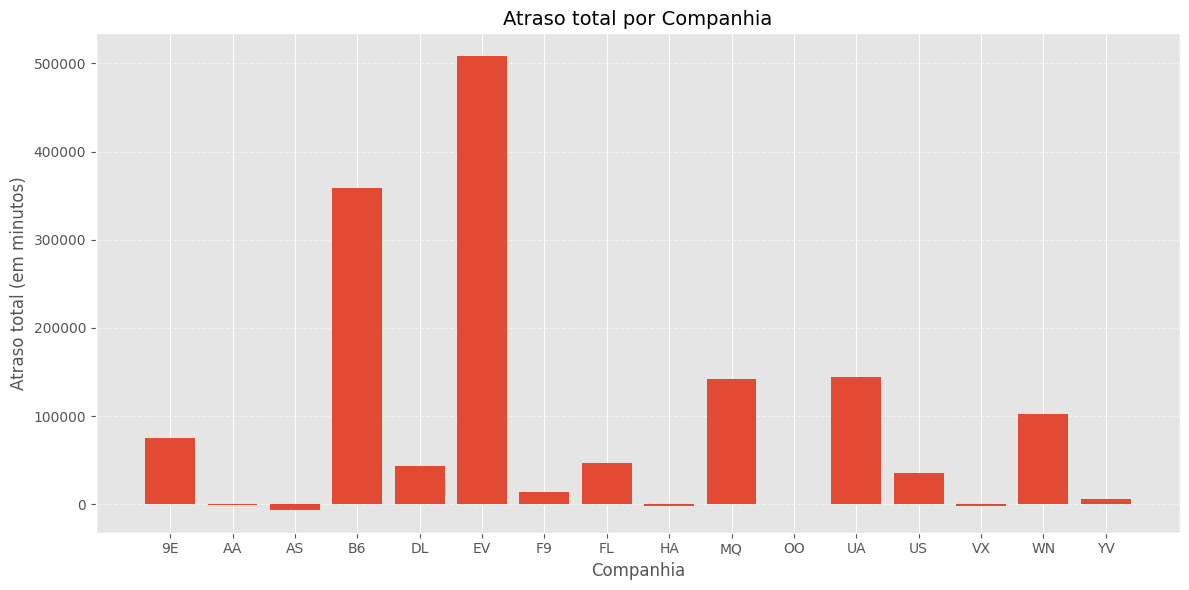

In [9]:
plt.style.use('ggplot')
plt.figure(figsize=(12,6))

plt.bar(total_atrasos.index, total_atrasos.values)


plt.title("Atraso total por Companhia", fontsize=14)
plt.xlabel("Companhia", fontsize=12)
plt.ylabel("Atraso total (em minutos)", fontsize=12)



plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()


plt.show()

In [10]:
volume_voos = df_clean['carrier'].value_counts().sort_values(ascending=True)

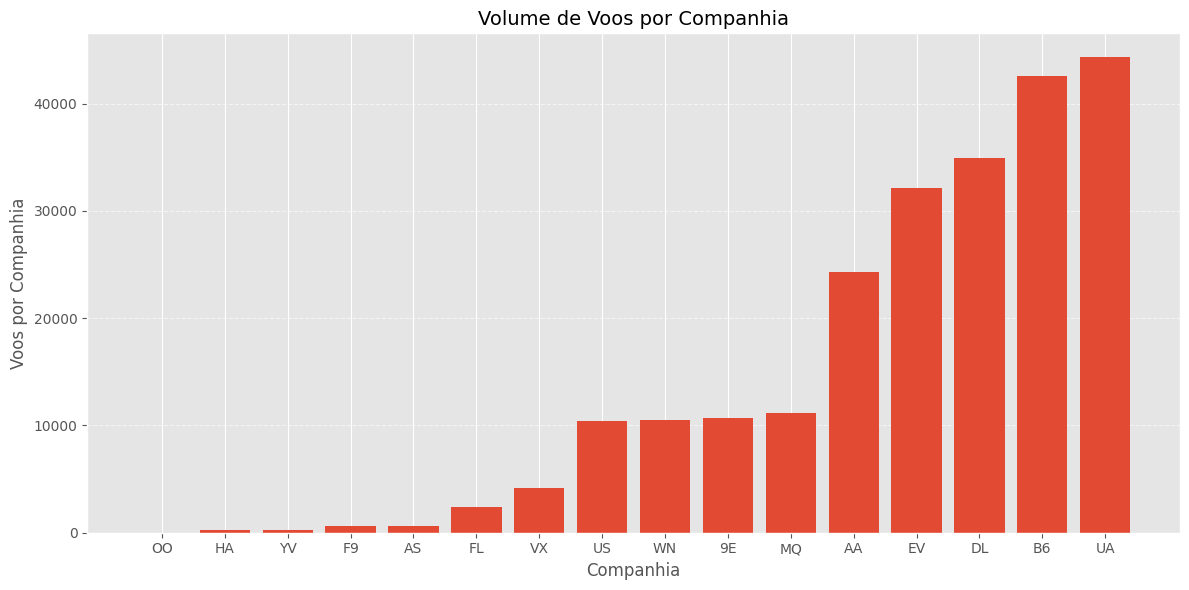

In [11]:
plt.style.use('ggplot')
plt.figure(figsize=(12,6))

plt.bar(volume_voos.index, volume_voos.values)


plt.title("Volume de Voos por Companhia", fontsize=14)
plt.xlabel("Companhia", fontsize=12)
plt.ylabel("Voos por Companhia", fontsize=12)



plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()


plt.show()

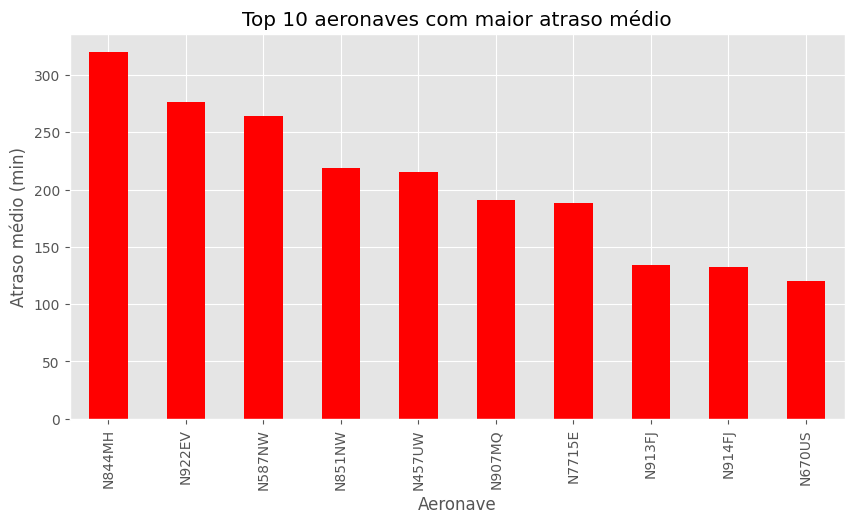

In [12]:
df_clean.groupby('tailnum')['arr_delay']\
    .mean()\
    .sort_values(ascending=False)\
    .head(10)\
    .plot(kind='bar', figsize=(10,5), color='red')
plt.title("Top 10 aeronaves com maior atraso médio")
plt.xlabel("Aeronave")
plt.ylabel("Atraso médio (min)")
plt.show()


In [16]:
df_clean = df_clean.copy()


df_clean['route'] = df_clean['origin'] + "-" + df_clean['dest']
df_clean.groupby('route')['arr_delay'].mean().sort_values(ascending=False).head(10)

route
EWR-GSO    212.000000
EWR-CAE     77.857143
EWR-CMH     68.750000
EWR-TYS     52.217391
EWR-OKC     50.020833
JFK-CLE     48.000000
LGA-TVC     47.000000
EWR-TUL     45.147059
EWR-DAY     38.902778
EWR-GSP     36.629870
Name: arr_delay, dtype: float64

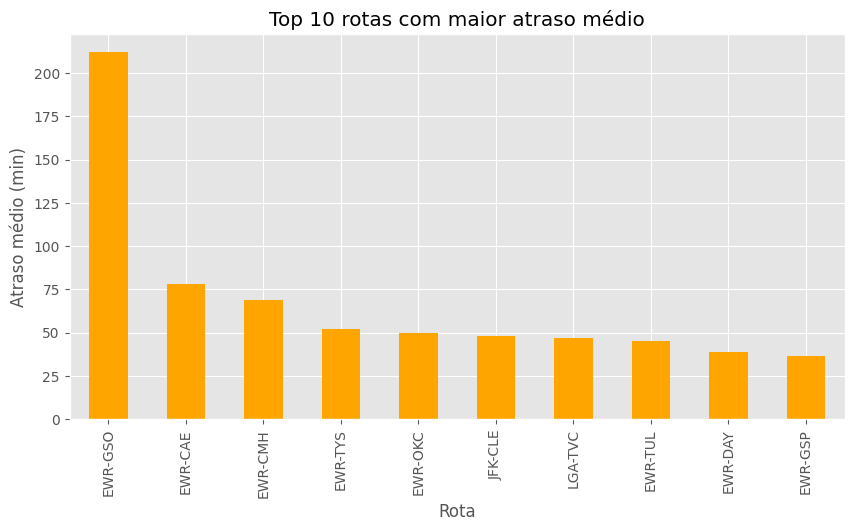

In [17]:
df_clean.groupby('route')['arr_delay']\
    .mean()\
    .sort_values(ascending=False)\
    .head(10)\
    .plot(kind='bar', figsize=(10,5), color='orange')
plt.title("Top 10 rotas com maior atraso médio")
plt.xlabel("Rota")
plt.ylabel("Atraso médio (min)")
plt.show()


In [22]:
df_clean['date'] = pd.to_datetime(df_clean[['year','month','day']])
df_clean['weekday'] = df_clean['date'].dt.day_name()

delay_by_weekday = df_clean.groupby('weekday')['arr_delay'].mean().loc[
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
]


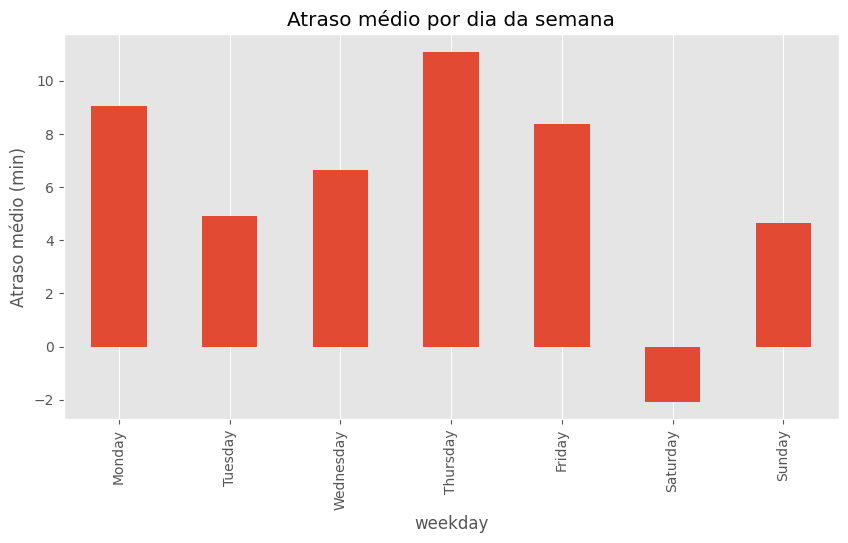

In [23]:
delay_by_weekday.plot(kind='bar', figsize=(10,5))
plt.title("Atraso médio por dia da semana")
plt.ylabel("Atraso médio (min)")
plt.grid(axis='y')
plt.show()


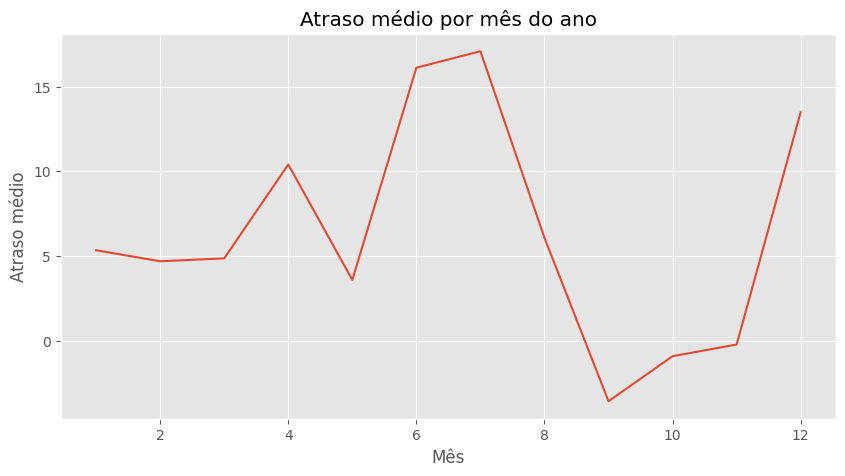

In [24]:
delay_by_month = df_clean.groupby('month')['arr_delay'].mean()

plt.figure(figsize=(10,5))
plt.plot(delay_by_month.index, delay_by_month.values)
plt.title("Atraso médio por mês do ano")
plt.xlabel("Mês")
plt.ylabel("Atraso médio")
plt.grid(True)
plt.show()


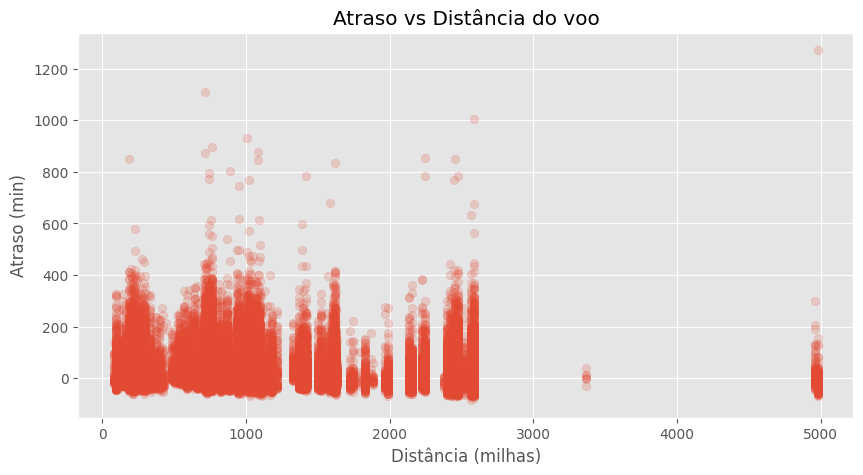

In [25]:
plt.figure(figsize=(10,5))
plt.scatter(df_clean['distance'], df_clean['arr_delay'], alpha=0.2)
plt.title("Atraso vs Distância do voo")
plt.xlabel("Distância (milhas)")
plt.ylabel("Atraso (min)")
plt.grid(True)
plt.show()


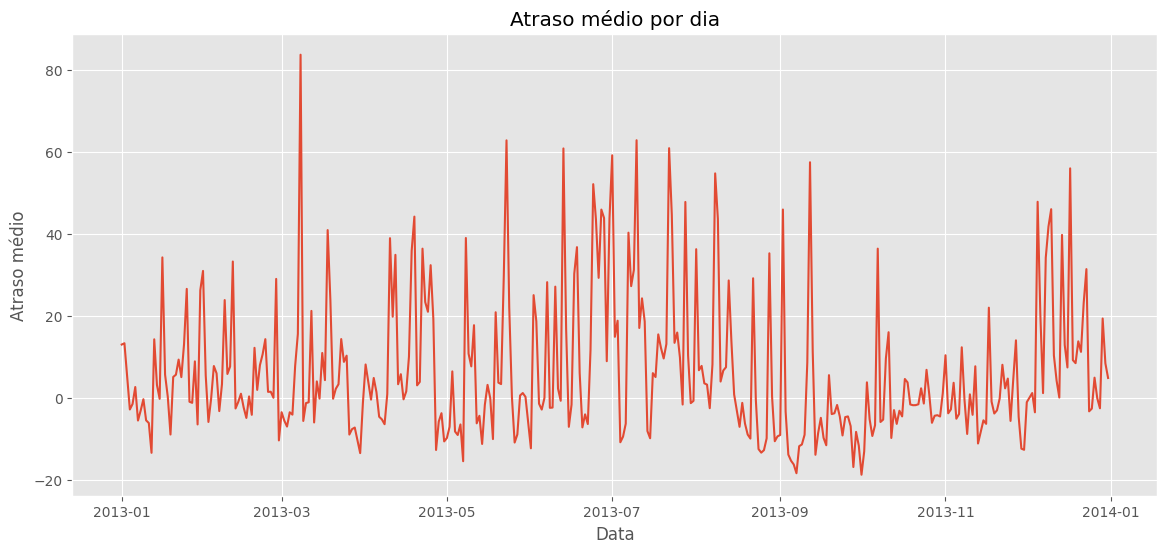

In [26]:
daily_delay = df_clean.groupby('date')['arr_delay'].mean()

plt.figure(figsize=(14,6))
plt.plot(daily_delay.index, daily_delay.values)
plt.title("Atraso médio por dia")
plt.xlabel("Data")
plt.ylabel("Atraso médio")
plt.grid(True)
plt.show()
